---
# Stage 2 – Data Collection & Data Understanding <a id='stage2'></a>

## 2.1 Dataset Overview

### UCI HAR Dataset
- **Source:** UC Irvine Machine Learning Repository  
  https://archive.ics.uci.edu/ml/datasets/human+activity+recognition+using+smartphones
- **Subjects:** 30 volunteers aged 19–48 years
- **Device:** Samsung Galaxy S II worn at the waist
- **Sampling Rate:** 50 Hz
- **Window:** 2.56 seconds, 50% overlap → 128 readings per window
- **Split:** 70% training (21 subjects), 30% testing (9 subjects)

### Data Files Structure
```
UCI HAR Dataset/
├── activity_labels.txt          ← 6 class labels
├── features.txt                 ← 561 feature names
├── features_info.txt            ← Feature descriptions
├── train/
│   ├── X_train.txt              ← 7352 × 561 pre-computed features
│   ├── y_train.txt              ← 7352 labels
│   ├── subject_train.txt        ← subject ID per sample
│   └── Inertial Signals/        ← raw sensor windows
│       ├── body_acc_x_train.txt  (7352 × 128)
│       ├── body_acc_y_train.txt
│       ├── body_acc_z_train.txt
│       ├── body_gyro_x_train.txt
│       ├── body_gyro_y_train.txt
│       ├── body_gyro_z_train.txt
│       ├── total_acc_x_train.txt
│       ├── total_acc_y_train.txt
│       └── total_acc_z_train.txt
└── test/
    └── (same structure as train)
```

In [4]:
# Stage 2 – Global Configuration
import os
import warnings
warnings.filterwarnings('ignore')

# Dataset paths
DATA_ROOT = 'UCI HAR Dataset'
TRAIN_PATH = os.path.join(DATA_ROOT, 'train')
TEST_PATH = os.path.join(DATA_ROOT, 'test')

# Signal/window parameters
WINDOW_SIZE = 128
OVERLAP = 64
SAMPLE_RATE = 50

# Activity mapping
ACTIVITY_MAP = {
    1: 'Walking',
    2: 'Walking Upstairs',
    3: 'Walking Downstairs',
    4: 'Sitting',
    5: 'Standing',
    6: 'Laying'
}

# Raw channel order in UCI HAR
SIGNAL_NAMES = [
    'body_acc_x', 'body_acc_y', 'body_acc_z',
    'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
    'total_acc_x', 'total_acc_y', 'total_acc_z'
 ]

print('Configuration loaded for Stage 2.')
print(f'Data root: {DATA_ROOT}')

Configuration loaded for Stage 2.
Data root: UCI HAR Dataset


In [5]:
import urllib.request
import zipfile
import os
import shutil

UCI_URL  = 'https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip'
ZIP_PATH = 'har_dataset.zip' # This might get overwritten if 'UCI HAR Dataset.zip' is found.

# Flag to track if download/extraction happened
data_extracted = False

# This block handles incomplete previous downloads
if os.path.exists('UCI HAR Dataset.zip'): # Check for the name the URL would give
    print("Found existing UCI HAR Dataset.zip, extracting...")
    ZIP_PATH = 'UCI HAR Dataset.zip' # Use the existing zip file
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall('.')
    os.remove(ZIP_PATH) # Remove the zip after extraction
    print("Extraction complete.")
    data_extracted = True

elif not os.path.exists(DATA_ROOT): # If DATA_ROOT (the folder) doesn't exist
    print("Downloading UCI HAR Dataset (~60 MB)...")
    urllib.request.urlretrieve(UCI_URL, ZIP_PATH)
    print("Download complete. Extracting...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall('.')
    os.remove(ZIP_PATH)
    print("Extraction complete.")
    data_extracted = True
else:
    print(f"Dataset already present at '{DATA_ROOT}'.")

# Handle nested directory structure after extraction if it occurred
if data_extracted:
    potential_data_roots = []
    for root, dirs, files in os.walk('.'):
        # A valid data root must contain 'train', 'test' dirs and 'features.txt' file
        if 'train' in dirs and 'test' in dirs and 'features.txt' in files:
            potential_data_roots.append(root)

    found_data_dir = None
    if potential_data_roots:
        # Choose the deepest (most specific) path as the actual data root
        found_data_dir = max(potential_data_roots, key=len)

    if found_data_dir and os.path.relpath(found_data_dir, '.') != DATA_ROOT:
        print(f"Data found at '{found_data_dir}'. Moving to expected '{DATA_ROOT}'...")
        # Clean up the target DATA_ROOT if it's an empty shell or incorrect
        if os.path.exists(DATA_ROOT):
            shutil.rmtree(DATA_ROOT)
        shutil.move(found_data_dir, DATA_ROOT)
        print("Data directory corrected.")
    elif not found_data_dir:
        print("Warning: Could not find 'train', 'test', and 'features.txt' in extracted data.")

# Re-evaluate TRAIN_PATH and TEST_PATH as DATA_ROOT might have been corrected
TRAIN_PATH  = os.path.join(DATA_ROOT, 'train')
TEST_PATH   = os.path.join(DATA_ROOT, 'test')


Dataset already present at 'UCI HAR Dataset'.


In [6]:
# ─── Load Pre-computed Feature Vectors (561-dim) ─────────────────────────────
import numpy as np
import pandas as pd

def load_har_features(data_root='UCI HAR Dataset'):
    """Load the 561-dimensional pre-computed feature matrices."""
    X_train = pd.read_csv(
        os.path.join(data_root, 'train', 'X_train.txt'),
        sep='\s+', header=None
    ).values
    X_test = pd.read_csv(
        os.path.join(data_root, 'test', 'X_test.txt'),
        sep='\s+', header=None
    ).values

    y_train = pd.read_csv(
        os.path.join(data_root, 'train', 'y_train.txt'),
        header=None
    ).values.ravel()
    y_test = pd.read_csv(
        os.path.join(data_root, 'test', 'y_test.txt'),
        header=None
    ).values.ravel()

    subj_train = pd.read_csv(
        os.path.join(data_root, 'train', 'subject_train.txt'),
        header=None
    ).values.ravel()
    subj_test = pd.read_csv(
        os.path.join(data_root, 'test', 'subject_test.txt'),
        header=None
    ).values.ravel()

    features = pd.read_csv(
        os.path.join(data_root, 'features.txt'),
        sep='\s+', header=None
    )[1].tolist()

    return X_train, X_test, y_train, y_test, subj_train, subj_test, features

X_train, X_test, y_train, y_test, subj_train, subj_test, feature_names = \
    load_har_features(DATA_ROOT)

print("=== Feature Data Loaded ===")
print(f"X_train shape : {X_train.shape}   (samples × features)")
print(f"X_test  shape : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test  shape : {y_test.shape}")
print(f"Number of features : {len(feature_names)}")
print(f"Training subjects  : {sorted(np.unique(subj_train))}")
print(f"Test subjects      : {sorted(np.unique(subj_test))}")

=== Feature Data Loaded ===
X_train shape : (7352, 561)   (samples × features)
X_test  shape : (2947, 561)
y_train shape : (7352,)
y_test  shape : (2947,)
Number of features : 561
Training subjects  : [np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]
Test subjects      : [np.int64(2), np.int64(4), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(18), np.int64(20), np.int64(24)]


In [7]:
# ─── Load Raw Inertial Signals ───────────────────────────────────────────────
def load_raw_signals(split_path, signal_names):
    """Load all 9 raw sensor channels → ndarray (samples, timesteps, channels)."""
    inertial_path = os.path.join(split_path, 'Inertial Signals')
    split_tag = 'train' if 'train' in split_path else 'test'
    signals = []
    for name in signal_names:
        fpath = os.path.join(inertial_path, f'{name}_{split_tag}.txt')
        arr = pd.read_csv(fpath, sep='\s+', header=None).values
        signals.append(arr)
    return np.stack(signals, axis=-1)   # → (N, 128, 9)

print("Loading raw inertial signals (this may take ~30 seconds)...")
X_raw_train = load_raw_signals(TRAIN_PATH, SIGNAL_NAMES)
X_raw_test  = load_raw_signals(TEST_PATH,  SIGNAL_NAMES)

print(f"X_raw_train shape : {X_raw_train.shape}   (samples, timesteps, channels)")
print(f"X_raw_test  shape : {X_raw_test.shape}")
print(f"Channels          : {SIGNAL_NAMES}")

Loading raw inertial signals (this may take ~30 seconds)...
X_raw_train shape : (7352, 128, 9)   (samples, timesteps, channels)
X_raw_test  shape : (2947, 128, 9)
Channels          : ['body_acc_x', 'body_acc_y', 'body_acc_z', 'body_gyro_x', 'body_gyro_y', 'body_gyro_z', 'total_acc_x', 'total_acc_y', 'total_acc_z']


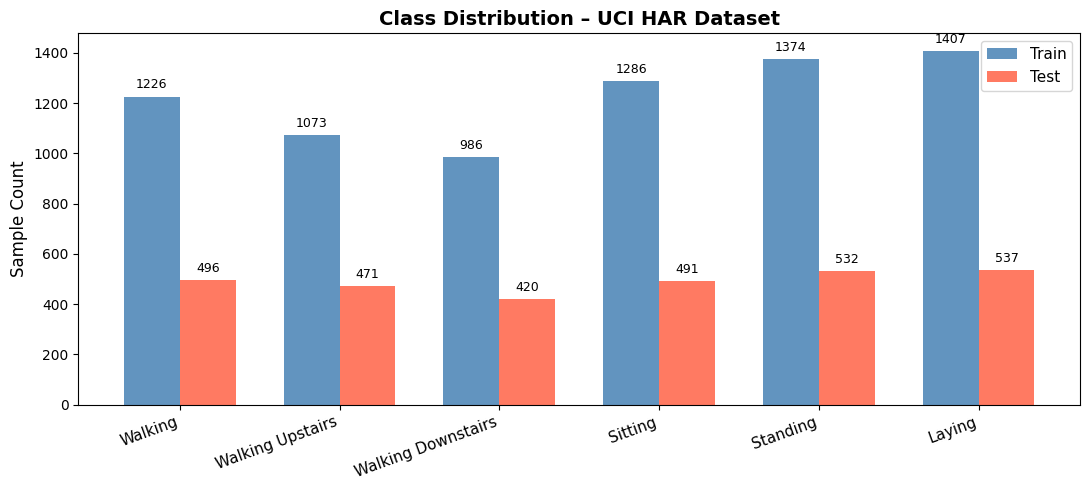

Saved: stage2_class_distribution.png

--- Train class counts ---
  Walking                :  1226
  Walking Upstairs       :  1073
  Walking Downstairs     :   986
  Sitting                :  1286
  Standing               :  1374
  Laying                 :  1407

--- Test class counts ---
  Walking                :   496
  Walking Upstairs       :   471
  Walking Downstairs     :   420
  Sitting                :   491
  Standing               :   532
  Laying                 :   537


In [ ]:
# ─── Class Distribution Analysis ─────────────────────────────────────────────
import matplotlib.pyplot as plt

def plot_class_distribution(y_train, y_test, activity_map):
    labels = [activity_map[i] for i in sorted(activity_map)]
    train_counts = [np.sum(y_train == i) for i in sorted(activity_map)]
    test_counts  = [np.sum(y_test  == i) for i in sorted(activity_map)]

    x = np.arange(len(labels))
    w = 0.35

    fig, ax = plt.subplots(figsize=(11, 5))
    bars1 = ax.bar(x - w/2, train_counts, w, label='Train', color='steelblue', alpha=0.85)
    bars2 = ax.bar(x + w/2, test_counts,  w, label='Test',  color='tomato',    alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=11)
    ax.set_ylabel('Sample Count', fontsize=12)
    ax.set_title('Class Distribution – UCI HAR Dataset', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig('outputs/stage2_class_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: outputs/stage2_class_distribution.png")

plot_class_distribution(y_train, y_test, ACTIVITY_MAP)

# Print counts
print("\n--- Train class counts ---")
for k, v in ACTIVITY_MAP.items():
    print(f"  {v:<22} : {np.sum(y_train == k):>5}")
print("\n--- Test class counts ---")
for k, v in ACTIVITY_MAP.items():
    print(f"  {v:<22} : {np.sum(y_test == k):>5}")

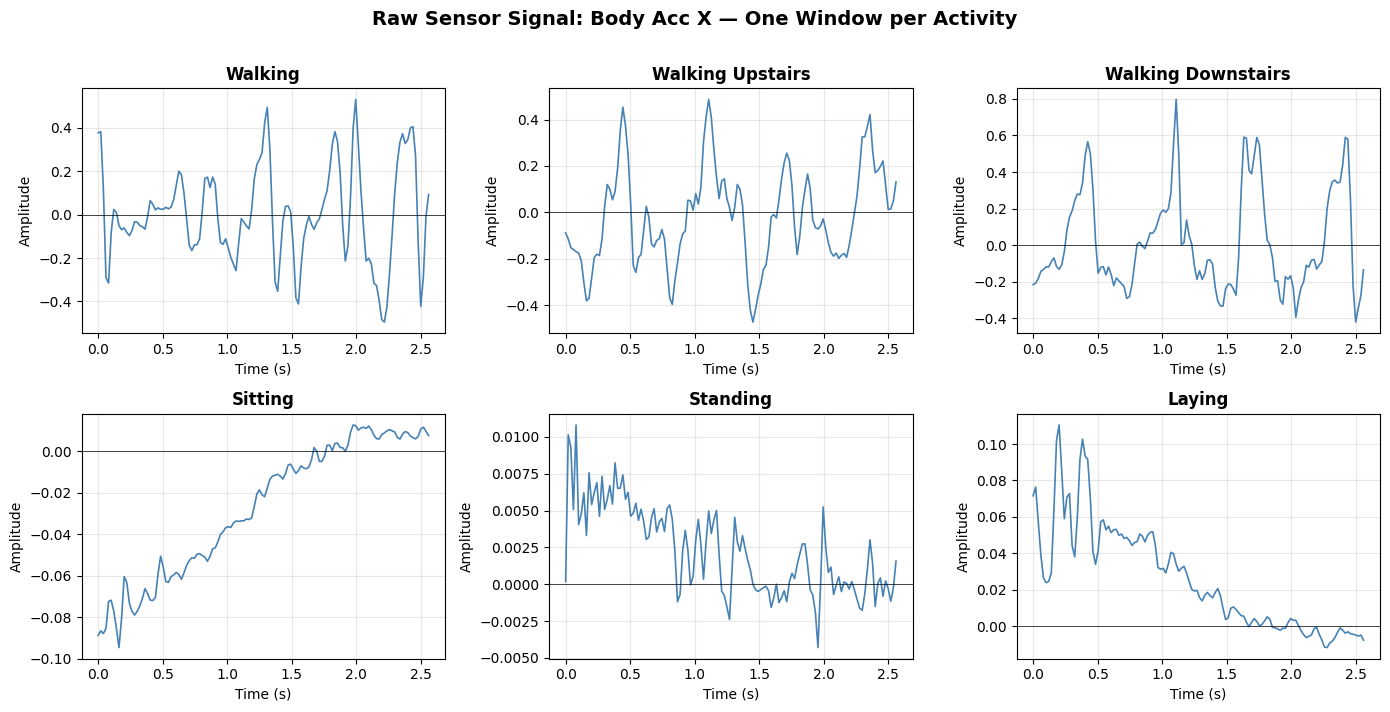

Saved: stage2_raw_signals.png


In [ ]:
# ─── Visualise Raw Sensor Signals per Activity ───────────────────────────────
def plot_raw_signals_per_activity(X_raw, y, activity_map, channel=0, channel_name='Body Acc X'):
    """
    Plot one representative window of a sensor channel for each activity.
    channel: index into the 9-channel axis
    """
    activities = sorted(activity_map.keys())
    fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=False)
    axes = axes.flatten()

    t = np.linspace(0, WINDOW_SIZE / SAMPLE_RATE, WINDOW_SIZE)

    for ax, act_id in zip(axes, activities):
        idx = np.where(y == act_id)[0][0]      # first matching sample
        signal = X_raw[idx, :, channel]
        ax.plot(t, signal, color='steelblue', linewidth=1.2)
        ax.set_title(activity_map[act_id], fontsize=12, fontweight='bold')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Amplitude')
        ax.grid(True, alpha=0.3)
        ax.axhline(0, color='k', linewidth=0.5)

    fig.suptitle(f'Raw Sensor Signal: {channel_name} — One Window per Activity',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('outputs/stage2_raw_signals.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: outputs/stage2_raw_signals.png")

plot_raw_signals_per_activity(X_raw_train, y_train, ACTIVITY_MAP,
                               channel=0, channel_name='Body Acc X')

In [10]:
# ─── Subject-Level Analysis ───────────────────────────────────────────────────
print("=== Subject-Level Summary ===")
for split, y, subj in [('Train', y_train, subj_train), ('Test', y_test, subj_test)]:
    subj_ids = sorted(np.unique(subj))
    print(f"\n{split} split — {len(subj_ids)} subjects: {subj_ids}")

# Verify no subject overlap between train and test
overlap = set(subj_train) & set(subj_test)
print(f"\nSubject overlap between train & test: {overlap if overlap else 'None ✓'}")
print("→ Person-independent evaluation is guaranteed.")

# Samples per subject (train)
subj_counts_df = pd.DataFrame({'subject': subj_train, 'label': y_train})
print("\nSamples per training subject:")
print(subj_counts_df.groupby('subject')['label'].count().to_string())

=== Subject-Level Summary ===

Train split — 21 subjects: [np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]

Test split — 9 subjects: [np.int64(2), np.int64(4), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(18), np.int64(20), np.int64(24)]

Subject overlap between train & test: None ✓
→ Person-independent evaluation is guaranteed.

Samples per training subject:
subject
1     347
3     341
5     302
6     325
7     308
8     281
11    316
14    323
15    328
16    366
17    368
19    360
21    408
22    321
23    372
25    409
26    392
27    376
28    382
29    344
30    383


In [11]:
# ─── Feature Vector Peek ───────────────────────────────────────────────────────
df_features = pd.DataFrame(X_train, columns=feature_names)
df_features['activity'] = y_train
df_features['activity_name'] = df_features['activity'].map(ACTIVITY_MAP)

print("=== Feature DataFrame (first 5 rows, first 10 features) ===")
display(df_features.iloc[:5, :10])

print("\n=== Descriptive Statistics (first 10 features) ===")
display(df_features.iloc[:, :10].describe().round(4))

=== Feature DataFrame (first 5 rows, first 10 features) ===


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469



=== Descriptive Statistics (first 10 features) ===


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X
count,7352.0000,7352.0000,7352.0000,7352.0000,7352.0000,7352.0000,7352.0000,7352.0000,7352.0000,7352.0000
mean,0.2745,-0.0177,-0.1091,-0.6054,-0.5109,-0.6048,-0.6305,-0.5269,-0.6062,-0.4686
std,0.0703,0.0408,0.0566,0.4487,0.5026,0.4187,0.4241,0.4859,0.4141,0.5445
min,-1.0000,-1.0000,-1.0000,-1.0000,-0.9999,-1.0000,-1.0000,-1.0000,-1.0000,-1.0000
25%,0.2630,-0.0249,-0.1210,-0.9928,-0.9781,-0.9802,-0.9936,-0.9782,-0.9803,-0.9362
50%,0.2772,-0.0172,-0.1087,-0.9462,-0.8519,-0.8594,-0.9507,-0.8573,-0.8571,-0.8816
75%,0.2885,-0.0108,-0.0978,-0.2428,-0.0342,-0.2624,-0.2927,-0.0667,-0.2657,-0.0171
max,1.0000,1.0000,1.0000,1.0000,0.9162,1.0000,1.0000,0.9677,1.0000,1.0000


Top 20 features by variance:
   1. fBodyAccJerk-entropy()-X                 (var=0.5651)
   2. fBodyAccJerk-entropy()-Y                 (var=0.5425)
   3. tBodyAccJerkMag-entropy()                (var=0.5289)
   4. fBodyAcc-entropy()-X                     (var=0.5257)
   5. tGravityAcc-correlation()-X,Z            (var=0.5009)
   6. tGravityAcc-correlation()-Y,Z            (var=0.4958)
   7. tBodyGyroJerkMag-entropy()               (var=0.4952)
   8. tGravityAcc-energy()-X                   (var=0.4871)
   9. tGravityAcc-correlation()-X,Y            (var=0.4853)
  10. fBodyAccMag-entropy()                    (var=0.4661)
  11. tGravityAccMag-entropy()                 (var=0.4580)
  12. tBodyAccMag-entropy()                    (var=0.4580)
  13. fBodyBodyAccJerkMag-entropy()            (var=0.4490)
  14. fBodyAcc-entropy()-Y                     (var=0.4484)
  15. tBodyAccJerk-entropy()-X                 (var=0.4267)
  16. fBodyAccJerk-entropy()-Z                 (var=0.4152)
  17. tBody

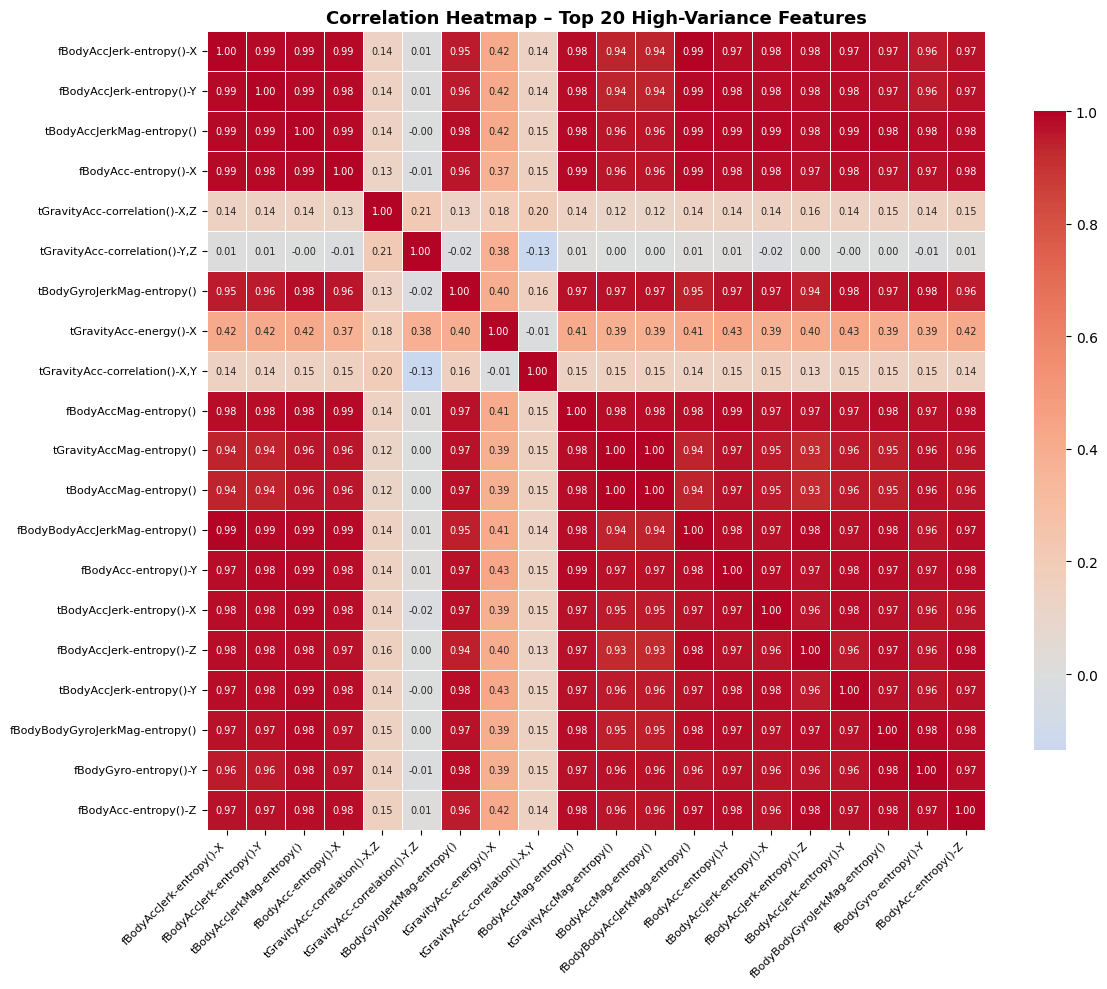

Saved: stage2_correlation_heatmap.png


In [ ]:
# ─── Correlation Heatmap (Top 20 Features) ───────────────────────────────────
import seaborn as sns

# Pick top 20 features by variance
variances = df_features.iloc[:, :-2].var().sort_values(ascending=False)
top20_feat = variances.head(20).index.tolist()

print(f"Top 20 features by variance:")
for i, feat in enumerate(top20_feat, 1):
    print(f"  {i:2d}. {feat:<40} (var={variances[feat]:.4f})")

corr_matrix = df_features[top20_feat].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.4, ax=ax, cbar_kws={'shrink': 0.8}, annot_kws={'size': 7})
ax.set_title('Correlation Heatmap – Top 20 High-Variance Features',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig('outputs/stage2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/stage2_correlation_heatmap.png")

In [13]:
# ─── Missing Value & Data Quality Check ──────────────────────────────────────
print("=== Data Quality Report ===")
for name, arr in [('X_train', X_train), ('X_test', X_test),
                  ('X_raw_train', X_raw_train), ('X_raw_test', X_raw_test)]:
    nans = np.sum(np.isnan(arr))
    infs = np.sum(np.isinf(arr))
    print(f"{name:<20} | shape={str(arr.shape):<22} "
          f"| NaN={nans:>4} | Inf={infs:>4}")

print("\n=== Label Quality ===")
print(f"y_train unique values : {np.unique(y_train)}")
print(f"y_test  unique values : {np.unique(y_test)}")
print(f"All expected labels present: "
      f"{set(np.unique(y_train)) == set(ACTIVITY_MAP.keys())}")

=== Data Quality Report ===
X_train              | shape=(7352, 561)            | NaN=   0 | Inf=   0
X_test               | shape=(2947, 561)            | NaN=   0 | Inf=   0
X_raw_train          | shape=(7352, 128, 9)         | NaN=   0 | Inf=   0
X_raw_test           | shape=(2947, 128, 9)         | NaN=   0 | Inf=   0

=== Label Quality ===
y_train unique values : [1 2 3 4 5 6]
y_test  unique values : [1 2 3 4 5 6]
All expected labels present: True
